In [9]:
!pip install yfinance
!pip install bs4
!pip install requests

import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

In [10]:
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")

tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [11]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0221EN-SkillsNetwork/labs/project/revenue.htm"

html_data = requests.get(url).text
soup = BeautifulSoup(html_data, "html.parser")

tables = soup.find_all("table")

tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        for row in table.find_all("tr")[1:]:
            col = row.find_all("td")
            if len(col) > 1:
                date = col[0].text
                revenue = col[1].text
                tesla_revenue = pd.concat([tesla_revenue, pd.DataFrame({"Date":[date], "Revenue":[revenue]})])

/tmp/ipykernel_15136/4122340271.py:4: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(html_data, "html.parser")


In [12]:
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(',', '')
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace('$', '')
tesla_revenue.dropna(inplace=True)

In [13]:
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")

gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712708,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [14]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0221EN-SkillsNetwork/labs/project/gamestop_revenue.htm"

html_data = requests.get(url).text
soup = BeautifulSoup(html_data, "html.parser")

tables = soup.find_all("table")

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in tables:
    if "GameStop Quarterly Revenue" in str(table):
        for row in table.find_all("tr")[1:]:
            col = row.find_all("td")
            if len(col) > 1:
                date = col[0].text
                revenue = col[1].text
                gme_revenue = pd.concat([gme_revenue, pd.DataFrame({"Date":[date], "Revenue":[revenue]})])

gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(',', '')
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace('$', '')
gme_revenue.dropna(inplace=True)

/tmp/ipykernel_15136/4008214822.py:4: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(html_data, "html.parser")


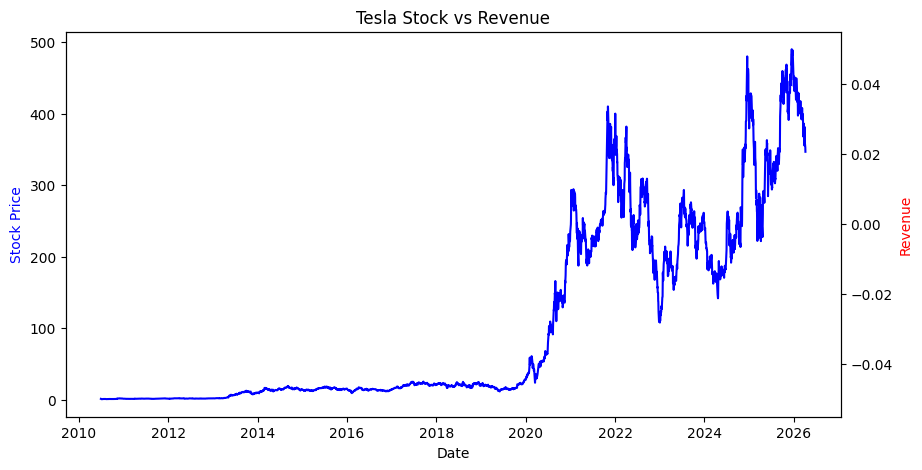

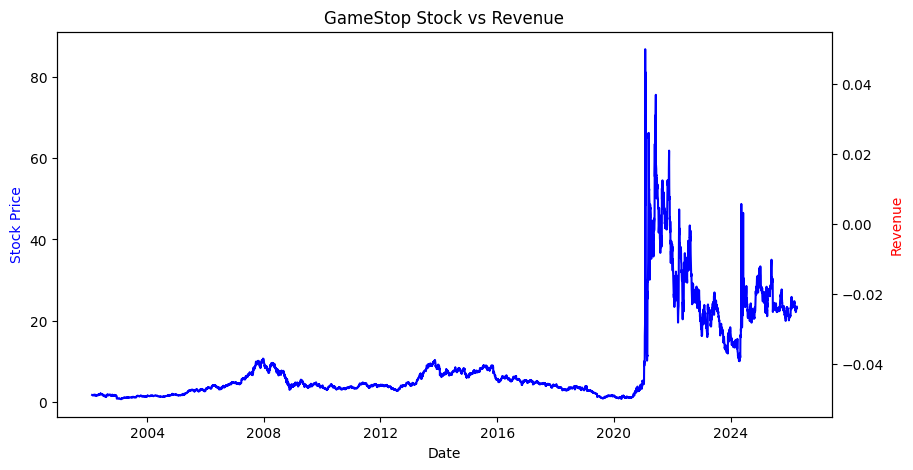

In [15]:
def make_graph(stock_data, revenue_data, title):
    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(stock_data["Date"], stock_data["Close"], color='blue')
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Stock Price", color='blue')

    ax2 = ax1.twinx()
    ax2.plot(pd.to_datetime(revenue_data["Date"]), revenue_data["Revenue"].astype("float"), color='red')
    ax2.set_ylabel("Revenue", color='red')

    plt.title(title)
    plt.show()

# Tesla Graph
make_graph(tesla_data, tesla_revenue, "Tesla Stock vs Revenue")

# GameStop Graph
make_graph(gme_data, gme_revenue, "GameStop Stock vs Revenue")